# Part A: Causal Inference Analysis

The objective of this notebook is to estimate the causal effect of a marketing campaign on customer conversion.

Unlike traditional predictive modeling, causal inference aims to determine whether the observed increase in conversions is truly caused by the marketing campaign rather than by differences in customer characteristics.

This notebook first investigates the treatment assignment mechanism and evaluates whether the assumptions required for causal inference are plausible. Multiple causal estimators are then implemented and compared to estimate the Average Treatment Effect (ATE) and Conditional Average Treatment Effect (CATE). Finally, the estimated treatment effects are interpreted from a business perspective to support campaign decision-making.

## 1. Import Libraries

This section prepares the dataset for causal inference analysis. The required libraries are imported, the dataset is loaded, and the variables used throughout the notebook are defined.

In [159]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from evaluation.balance import calculate_covariate_balance
from causal.propensity import fit_propensity_model
from uplift.t_learner import (
    estimate_cate,
    split_uplift_data,
    train_t_learner,
)

import importlib
import causal.estimators

importlib.reload(causal.estimators)

from causal.estimators import (
    difference_in_means,
    regression_adjustment,
    inverse_probability_weighting,
    doubly_robust,
)

from setup import configure_notebook

configure_notebook()

from features.configure import load_configuration

# 2. Load Configuration

Project-specific configurations, such as the dataset location and key variable names, are stored in a separate `.env` file.

Separating configuration from source code improves portability and makes it easier to reuse this notebook with different datasets.

In [161]:
from features.configure import load_configuration

config = load_configuration()

DATASET_PATH = config["dataset_path"]
TARGET = config["target"]
TREATMENT = config["treatment"]

print("Configuration Loaded")
print(f"Dataset Path     : {DATASET_PATH}")
print(f"Target Column    : {TARGET}")
print(f"Treatment Column : {TREATMENT}")

Configuration Loaded
Dataset Path     : /Users/baotram/Desktop/Criteo Uplift/Data/criteo-uplift-v2.1.csv
Target Column    : conversion
Treatment Column : treatment


# 3. Load Dataset

The dataset is loaded from the local machine using the file path specified in the configuration file.

After loading, the dataset is stored as a Pandas DataFrame, which will be used throughout the remainder of the analysis.

In [162]:

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.62,10.06,8.98,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
1,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
2,12.62,10.06,8.96,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
3,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
4,12.62,10.06,9.04,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0


### Variable Definition

For causal inference, only variables assumed to exist before treatment assignment are used as covariates.

The variables `f0`–`f11` are treated as pre-treatment customer characteristics.

`treatment` is the intervention variable, while `conversion` is the outcome of interest.

`visit` and `exposure` are excluded from the covariate set because they are assumed to occur after treatment and may therefore represent post-treatment variables.

In [163]:
# Pre-treatment covariates
PRE_TREATMENT_FEATURES = [f"f{i}" for i in range(12)]

# Treatment and outcome
TREATMENT = "treatment"
OUTCOME = "conversion"

X = df[PRE_TREATMENT_FEATURES]
T = df[TREATMENT]
Y = df[OUTCOME]

### 2.4 Verify Variable Structure

Before proceeding with the causal analysis, the defined variables are verified to ensure that:

- all selected columns exist in the dataset;
- the feature matrix, treatment variable, and outcome variable contain the same number of observations;
- the treatment and outcome variables are binary;
- there are no missing values in the variables used for the analysis.

This verification helps prevent data preparation errors from affecting subsequent causal inference results.

In [165]:
# Verify variable structure
print("Dataset shape:", df.shape)

print("\nPre-treatment feature matrix shape:", X.shape)
print("Number of pre-treatment features:", X.shape[1])
print("Pre-treatment features:", list(X.columns))

print("\nTreatment distribution:")
print(T.value_counts(dropna=False).sort_index())

print("\nOutcome distribution:")
print(Y.value_counts(dropna=False).sort_index())

print("\nMissing values:")
print("X:", X.isna().sum().sum())
print("T:", T.isna().sum())
print("Y:", Y.isna().sum())

print("\nBinary-variable checks:")
print("Treatment unique values:", sorted(T.dropna().unique()))
print("Outcome unique values:", sorted(Y.dropna().unique()))

print("\nIndex alignment:")
print("X and T aligned:", X.index.equals(T.index))
print("X and Y aligned:", X.index.equals(Y.index))

Dataset shape: (13979592, 16)

Pre-treatment feature matrix shape: (13979592, 12)
Number of pre-treatment features: 12
Pre-treatment features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

Treatment distribution:
treatment
0     2096937
1    11882655
Name: count, dtype: int64

Outcome distribution:
conversion
0    13938818
1       40774
Name: count, dtype: int64

Missing values:
X: 0
T: 0
Y: 0

Binary-variable checks:
Treatment unique values: [np.int64(0), np.int64(1)]
Outcome unique values: [np.int64(0), np.int64(1)]

Index alignment:
X and T aligned: True
X and Y aligned: True


### Inspect the Unique Values of Treatment and Outcome

The treatment (`treatment`) and outcome (`conversion`) variables were examined to verify that they are binary variables suitable for causal inference analysis.

The treatment variable contains two unique values (0 and 1), indicating whether a customer belongs to the control or treatment group.

The outcome variable also contains two unique values (0 and 1), indicating whether a customer converted after the marketing campaign.

In [166]:
# Inspect the unique values of treatment and outcome
binary_variable_check = pd.DataFrame({
    "Variable": [
        TREATMENT,
        OUTCOME
    ],
    "Unique Values": [
        sorted(T.dropna().unique().tolist()),
        sorted(Y.dropna().unique().tolist())
    ],
    "Number of Unique Values": [
        T.nunique(dropna=True),
        Y.nunique(dropna=True)
    ]
})

display(binary_variable_check)

,Variable,Unique Values,Number of Unique Values
0,treatment,"[0, 1]",2
1,conversion,"[0, 1]",2


### Verify That X, T, and Y Contain the Same Number of Observations

The feature matrix (`X`), treatment variable (`T`), and outcome variable (`Y`) were checked to ensure that they contain the same number of observations and are correctly aligned.

This verification confirms that each customer has a corresponding set of pre-treatment covariates, treatment assignment, and observed outcome, ensuring consistency for subsequent causal analysis.

In [167]:
# Verify that X, T, and Y contain the same number of observations
shape_check = pd.DataFrame({
    "Object": [
        "Feature matrix X",
        "Treatment T",
        "Outcome Y"
    ],
    "Shape": [
        str(X.shape),
        str(T.shape),
        str(Y.shape)
    ]
})

display(shape_check)

assert len(X) == len(T) == len(Y), (
    "X, T, and Y do not contain the same number of observations."
)

,Object,Shape
0,Feature matrix X,"(13979592, 12)"
1,Treatment T,"(13979592,)"
2,Outcome Y,"(13979592,)"


### Findings

The feature matrix (X) contains 13,979,592 observations and 12 pre-treatment features, while the treatment (T) and outcome (Y) variables contain the same number of observations. This confirms that all three objects are structurally consistent and can be used together for subsequent causal inference analysis.

### Implication

The consistent dimensions of X, T, and Y indicate that each observation is correctly represented by a corresponding set of pre-treatment covariates, treatment assignment, and outcome. This minimizes the risk of misalignment during subsequent causal inference analyses.

### Decision
Proceed with exploratory data analysis and covariate balance assessment using the validated feature matrix, treatment, and outcome variables.

## 3. Treatment Assignment Analysis

Treatment assignment is examined to understand how observations are allocated between the treatment and control groups and whether pre-treatment customer characteristics may influence this allocation.

This analysis includes the treatment distribution, covariate balance assessment, treatment-assignment modelling, and propensity-score diagnostics.

### 3.1 Treatment Distribution

This analysis summarises the number and proportion of customers assigned to the treatment and control groups.

A balanced treatment allocation generally improves the precision of treatment effect estimation, while a highly imbalanced allocation may require additional consideration during causal modelling.

In [106]:
# Number of customers in each treatment group
treatment_count = (
    df[TREATMENT]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Control",
        1: "Treatment"
    })
)

# Percentage of customers in each treatment group
treatment_percentage = (
    df[TREATMENT]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Control",
        1: "Treatment"
    })
)

treatment_distribution = pd.DataFrame({
    "Number of Customers": treatment_count,
    "Percentage (%)": treatment_percentage.round(2)
})

display(treatment_distribution)

,Number of Customers,Percentage (%)
treatment,,
Control,2096937,15.00
Treatment,11882655,85.00


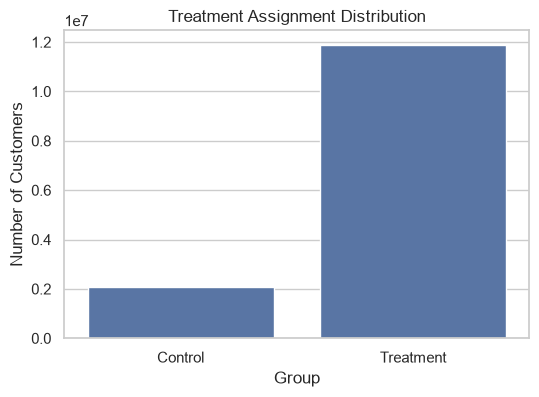

In [168]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=TREATMENT
)

plt.xticks(
    [0,1],
    ["Control","Treatment"]
)

plt.title("Treatment Assignment Distribution")

plt.xlabel("Group")

plt.ylabel("Number of Customers")

plt.show()

### Findings
The treatment assignment is highly imbalanced. Approximately 85% of customers belong to the treatment group, whereas only 15% belong to the control group.

### Implication

The unequal treatment allocation suggests that the treatment and control groups may not be directly comparable. As a result, it is necessary to assess whether the 12 pre-treatment covariates (f0–f11) are balanced between the two groups before estimating treatment effects.

### Decision

Proceed to evaluate the balance of the pre-treatment covariates between the treatment and control groups using standardized mean differences (SMD) and other covariate balance diagnostics.

### 3.2 Covariate Balance

Covariate balance was assessed to determine whether the treatment and control groups differed systematically in their observed pre-treatment characteristics.

Only the 12 variables `f0`–`f11` were included in this assessment because they are assumed to represent customer characteristics observed before treatment assignment. The post-treatment variables `visit` and `exposure` were excluded.

For each covariate, the mean and standard deviation were calculated separately for the treatment and control groups. Balance was evaluated using the standardized mean difference (SMD), which measures the difference between group means relative to their pooled variability.

An absolute SMD below 0.10 is commonly interpreted as evidence of acceptable covariate balance, while larger values may indicate potential imbalance.

In [169]:
from evaluation.balance import calculate_covariate_balance

balance_table = calculate_covariate_balance(X, T)

display(balance_table)

,Control Mean,Treatment Mean,Control SD,Treatment SD,Pooled SD,SMD,Absolute SMD,Balance Status
f3,4.23,4.17,1.24,1.35,1.30,-0.05,0.05,Balanced
f6,-4.00,-4.18,4.44,4.60,4.52,-0.04,0.04,Balanced
f5,4.04,4.03,0.40,0.44,0.42,-0.03,0.03,Balanced
f9,15.89,16.05,6.80,7.06,6.93,0.02,0.02,Balanced
f1,10.07,10.07,0.09,0.11,0.10,0.02,0.02,Balanced
f8,3.93,3.93,0.06,0.06,0.06,-0.02,0.02,Balanced
f7,5.08,5.11,1.16,1.21,1.19,0.02,0.02,Balanced
f10,5.33,5.33,0.16,0.17,0.17,0.01,0.01,Balanced
f4,10.34,10.34,0.34,0.34,0.34,0.01,0.01,Balanced
f0,19.65,19.61,5.39,5.38,5.38,-0.01,0.01,Balanced


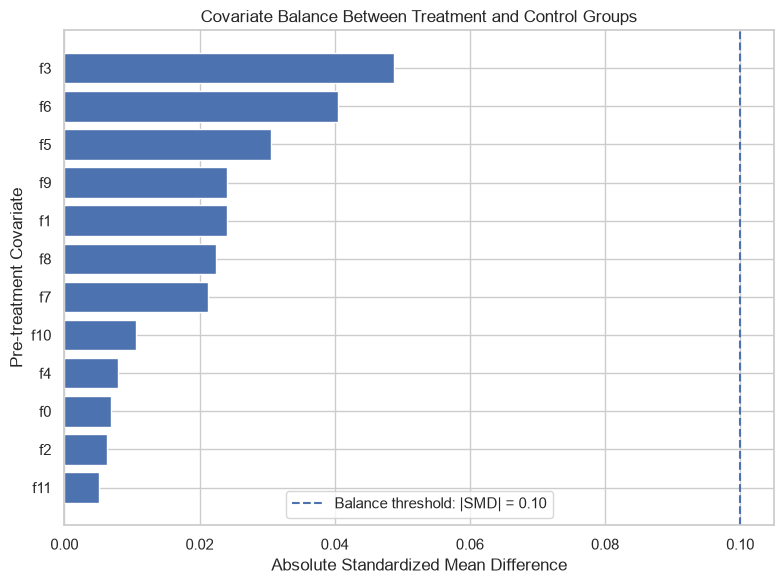

In [170]:
import matplotlib.pyplot as plt

smd_plot = balance_table.sort_values(
    by="Absolute SMD",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    smd_plot.index,
    smd_plot["Absolute SMD"]
)

plt.axvline(
    x=0.1,
    linestyle="--",
    label="Balance threshold: |SMD| = 0.10"
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Pre-treatment Covariate")
plt.title("Covariate Balance Between Treatment and Control Groups")
plt.legend()
plt.tight_layout()
plt.show()

#### Findings

All 12 pre-treatment covariates are balanced between the treatment and control groups based on the absolute standardized mean difference threshold of 0.10.

The largest imbalance is observed for `f3`, with an absolute SMD of approximately **0.049**, followed by `f6` at approximately **0.040**. However, both values remain well below the 0.10 threshold.

The remaining covariates show even smaller differences, with absolute SMD values ranging from approximately **0.005** to **0.031**.

#### Implication

The treatment and control groups are similar with respect to the observed pre-treatment covariates `f0`–`f11`, despite the unequal group sizes identified in the treatment distribution analysis.

This reduces concern about substantial observed confounding arising from these measured covariates. However, covariate balance does not rule out the presence of unobserved confounders or guarantee that treatment assignment was completely random.

#### Decision

Proceed to model treatment assignment using the 12 pre-treatment covariates and examine the resulting propensity scores.

The next analysis will assess whether the combined covariate information can predict treatment assignment and whether sufficient overlap exists between the treatment and control groups.

### 3.3 Standardized Mean Difference (SMD)

The standardized mean difference (SMD) quantifies the magnitude of covariate differences between the treatment and control groups relative to their pooled variability.

Because SMD is scale-independent, it allows balance comparisons across covariates measured on different scales. An absolute SMD below **0.10** is interpreted as evidence of acceptable covariate balance.

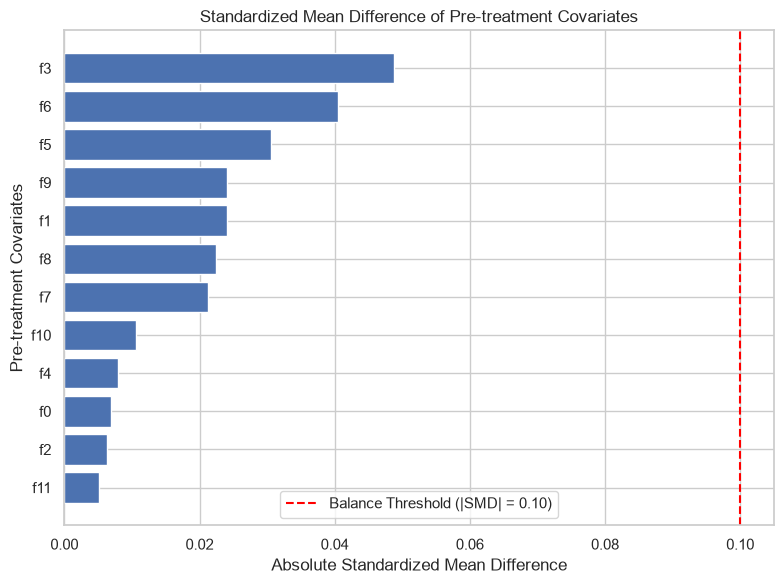

In [171]:
import matplotlib.pyplot as plt

plot_data = balance_table.sort_values(
    by="Absolute SMD",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data.index,
    plot_data["Absolute SMD"]
)

plt.axvline(
    x=0.10,
    color="red",
    linestyle="--",
    label="Balance Threshold (|SMD| = 0.10)"
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Pre-treatment Covariates")
plt.title("Standardized Mean Difference of Pre-treatment Covariates")
plt.legend()

plt.tight_layout()
plt.show()

#### Findings

The standardized mean difference analysis shows that all 12 pre-treatment covariates have absolute SMD values below the commonly accepted threshold of 0.10.

The largest absolute SMD is observed for `f3` (0.0488), followed by `f6` (0.0404) and `f5` (0.0306). The remaining covariates have even smaller standardized differences, ranging from 0.0052 to 0.0240.

Based on the predefined criterion, all pre-treatment covariates are classified as **Balanced**.

#### Implication

The consistently low standardized mean differences indicate that the treatment and control groups are highly comparable with respect to the observed pre-treatment covariates. Therefore, substantial imbalance in the measured customer characteristics is unlikely to be a major source of bias when estimating treatment effects.

However, this assessment only applies to the observed covariates (`f0`–`f11`) and does not eliminate the possibility of unobserved confounding.

#### Decision

Proceed to estimate a treatment assignment model using logistic regression to calculate propensity scores. The resulting propensity scores will be used to evaluate whether sufficient overlap exists between the treatment and control groups for subsequent causal inference analyses.

### 3.4 Logistic Regression Predicting Treatment

A logistic regression model was fitted to estimate the probability of treatment assignment using the observed pre-treatment covariates (`f0`–`f11`).

In propensity score analysis, logistic regression is commonly used to model the treatment assignment mechanism. The predicted probabilities represent each observation's propensity score, defined as the probability of receiving treatment conditional on the observed covariates.

The estimated coefficients also provide insight into which observed covariates are more strongly associated with treatment assignment.

In [172]:
from causal.propensity import fit_propensity_model

propensity_result = fit_propensity_model(
    X=X,
    treatment=T,
)

propensity_model = propensity_result.model
propensity_scores = propensity_result.propensity_scores
coef_table = propensity_result.coefficient_table

df["propensity_score"] = propensity_scores

display(coef_table)

,Feature,Coefficient,Absolute Coefficient
0,f1,0.16,0.16
1,f8,0.06,0.06
2,f10,0.03,0.03
3,f4,-0.03,0.03
4,f3,-0.02,0.02
5,f11,0.01,0.01
6,f7,0.01,0.01
7,f6,-0.00,0.00
8,f2,0.00,0.00
9,f5,-0.00,0.00


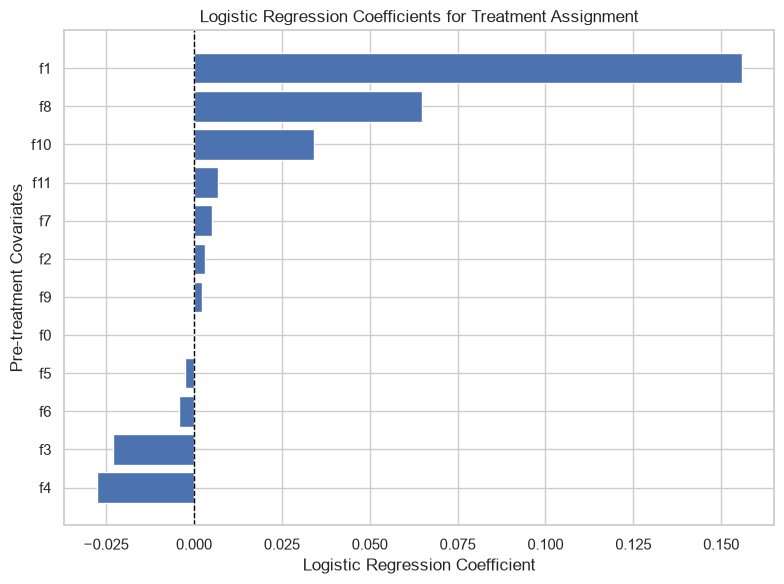

In [173]:
# Sort coefficients for visualization
coef_plot = coef_table.sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Pre-treatment Covariates")
plt.title("Logistic Regression Coefficients for Treatment Assignment")

plt.tight_layout()
plt.show()

#### Findings

The coefficient plot shows that the associations between the pre-treatment covariates and treatment assignment are generally small.

Among the observed covariates, `f1` has the strongest positive association with treatment assignment, followed by `f8` and `f10`. Conversely, `f4` and `f3` exhibit the strongest negative associations. The remaining covariates have coefficients close to zero, indicating relatively weak individual relationships with treatment assignment.

#### Implication

The visualization confirms that no single observed pre-treatment covariate dominates the treatment assignment mechanism. Instead, treatment assignment appears to be influenced by the combined effects of multiple covariates, each contributing relatively modestly.

These estimated coefficients are subsequently used to compute propensity scores rather than to interpret causal effects.

#### Decision

Proceed to examine the distribution of the estimated propensity scores for the treatment and control groups. Assessing the overlap between these distributions is essential for evaluating the common support assumption required for subsequent causal inference analyses.

### 3.5 Propensity Score Distribution

The estimated propensity scores were examined separately for the treatment and control groups.

A propensity score represents the estimated probability of receiving treatment conditional on the observed pre-treatment covariates.

Visualizing the propensity score distributions allows assessment of the **common support (overlap) assumption**, which requires observations from both treatment groups to share similar ranges of propensity scores.

Adequate overlap indicates that treated and control observations are comparable, supporting more reliable estimation of treatment effects.

In [174]:
propensity_summary = (
    df
    .groupby(TREATMENT)["propensity_score"]
    .describe()
)

propensity_summary

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,2096937.00,0.85,0.01,0.82,0.85,0.85,0.85,0.94
1,11882655.00,0.85,0.01,0.81,0.85,0.85,0.85,0.95


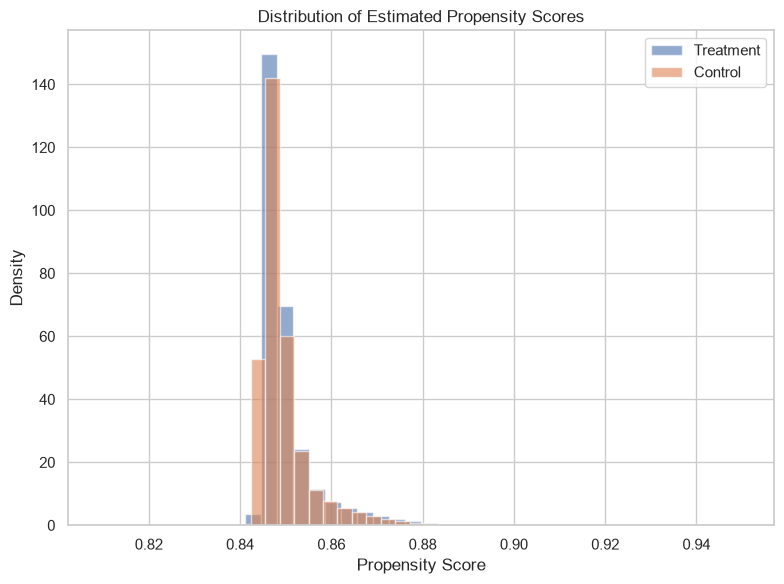

In [175]:
plt.figure(figsize=(8, 6))

plt.hist(
    df.loc[df[TREATMENT] == 1, "propensity_score"],
    bins=40,
    alpha=0.6,
    density=True,
    label="Treatment"
)

plt.hist(
    df.loc[df[TREATMENT] == 0, "propensity_score"],
    bins=40,
    alpha=0.6,
    density=True,
    label="Control"
)

plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.title("Distribution of Estimated Propensity Scores")

plt.legend()

plt.tight_layout()
plt.show()

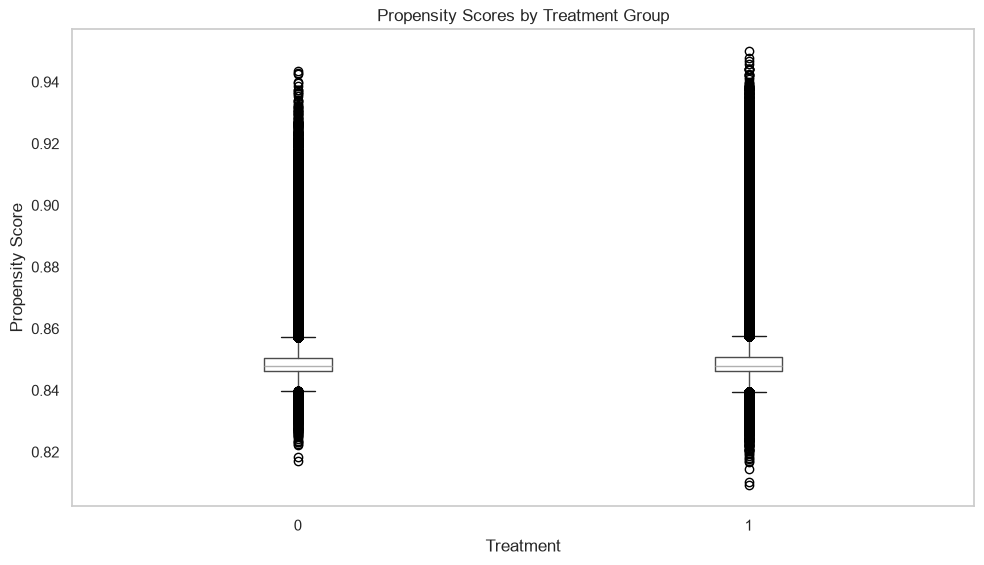

In [176]:
df.boxplot(
    column="propensity_score",
    by=TREATMENT,
    grid=False,
)

plt.suptitle("")
plt.title("Propensity Scores by Treatment Group")

plt.xlabel("Treatment")
plt.ylabel("Propensity Score")

plt.tight_layout()
plt.show()

#### Findings

The histogram shows substantial overlap between the estimated propensity score distributions of the treatment and control groups. Both groups are concentrated within a narrow propensity score range, with very similar distributional shapes and only minor differences in density.

The boxplot further confirms this observation. The treatment and control groups have nearly identical medians, interquartile ranges, and overall spread, although both groups contain several observations with more extreme propensity scores.

#### Implication

The strong overlap observed in both the histogram and boxplot provides visual evidence supporting the common support assumption. This indicates that treated and control observations are comparable across most of the observed covariate space, reducing concerns about limited overlap when estimating treatment effects.

Together with the earlier covariate balance analysis and the small logistic regression coefficients, these results suggest that treatment assignment is only weakly associated with the observed pre-treatment covariates.

#### Decision

The propensity score analysis indicates satisfactory overlap between the treatment and control groups. Therefore, the dataset is considered appropriate for proceeding to the uplift modeling stage, where individual treatment effects and customer uplift scores will be estimated.

# Part B: Causal Inference Framework

Before estimating customer-level treatment effects, it is necessary to establish a causal framework that defines the causal question, the assumed data-generating process, and the identification strategy.

This framework clarifies which variables should be adjusted for, which variables should be excluded from adjustment, and whether the assumptions required for causal effect estimation are reasonably supported by the available data.

The resulting framework provides the theoretical foundation for the uplift modeling approach developed in the following sections.

## 4.1 Research Question

The objective of this study is to estimate the incremental effect of a marketing campaign on customer conversion at the individual level.

Specifically, for each customer, the analysis seeks to estimate the Individual Treatment Effect (ITE), defined as the difference between the customer's potential conversion outcome if exposed to the campaign and the potential conversion outcome if not exposed.

These estimated treatment effects will subsequently be used to calculate customer uplift scores, rank customers according to expected incremental benefit, and support campaign targeting decisions.

## 4.2 Directed Acyclic Graph (DAG)

A Directed Acyclic Graph (DAG) is used to represent the assumed causal relationships between customer characteristics, treatment assignment, and conversion.

The pre-treatment customer features (`f0`–`f11`) may influence both the probability of receiving the marketing campaign and the probability of conversion. Therefore, these variables are treated as potential confounders.

The treatment variable represents whether a customer received the marketing campaign, while the outcome variable represents whether the customer converted.

Variables such as `visit` and `exposure` occur after treatment assignment and are therefore considered post-treatment variables. These variables are not included in the adjustment set because conditioning on post-treatment variables may block part of the treatment effect that the analysis aims to estimate.

           f0-f11
          /      \
         ▼        ▼
 Treatment ───► Conversion
      │
      ▼
 Visit / Exposure
      │
      ▼
 Conversion

 Adjustment Set:
✓ f0-f11

Excluded:
✗ visit
✗ exposure

## 4.3 Identification Strategy

Based on the assumed causal graph, the adjustment set consists of the observed pre-treatment customer characteristics (`f0`–`f11`).

These variables are included in the analysis because they may influence both treatment assignment and customer conversion, thereby acting as potential confounders.

Conversely, the variables `visit` and `exposure` are excluded from the adjustment set because they occur after treatment assignment. Including post-treatment variables could block part of the causal pathway between treatment and conversion, leading to biased estimates of the total treatment effect.

Therefore, all subsequent causal analyses and uplift models are constructed using only the identified pre-treatment covariates.

### 4.4.1 Consistency

The consistency assumption states that the observed outcome corresponds to the potential outcome under the treatment actually received.

This assumption requires that the treatment is clearly defined and consistently applied across all observations. In addition, each observation should have one observed treatment status and one corresponding observed outcome.

As verified during the data overview stage, the dataset contains a well-defined binary treatment indicator (`treatment`) and a binary outcome variable (`conversion`), with no missing values in either variable. Therefore, the consistency assumption is considered reasonable for this study.

### 4.4.2 Ignorability (Unconfoundedness)

The ignorability assumption states that, conditional on the observed pre-treatment covariates, treatment assignment is independent of the potential outcomes.

Although this assumption cannot be directly verified from observational data, its plausibility can be assessed using the covariate balance analyses conducted in Section 3.

The standardized mean difference analysis showed that all pre-treatment covariates (`f0`–`f11`) have absolute standardized mean differences below the commonly accepted threshold of 0.10. In addition, the logistic regression model indicated relatively weak associations between the observed covariates and treatment assignment.

Together, these findings suggest that the treatment and control groups are well balanced with respect to the observed covariates. Nevertheless, the possibility of unobserved confounding cannot be completely ruled out.

### 4.4.3 Positivity (Overlap)

The positivity assumption requires that every customer has a positive probability of receiving either treatment condition given the observed pre-treatment covariates.

This assumption is evaluated using the estimated propensity score distributions obtained in Section 3. The histogram and boxplot demonstrated substantial overlap between the treatment and control groups, with nearly identical medians, interquartile ranges, and overall distributions.

The observed overlap suggests that comparable treated and control customers exist across most of the observed covariate space, supporting the common support assumption required for causal effect estimation.

# Part C: Uplift Modeling

Having established the causal framework and assessed the plausibility of the identification assumptions, the next step is to develop an uplift model for estimating customer-level treatment effects.

Unlike conventional predictive models that estimate the probability of conversion, uplift models aim to estimate how each customer's outcome changes because of the marketing campaign. These estimated treatment effects enable more effective customer targeting by identifying individuals who are most likely to benefit from treatment.

This section presents the model selection process, model training procedure, and estimation of individual treatment effects.

## 5.1 Model Selection

Several approaches have been proposed for estimating Individual Treatment Effects (ITEs), including meta-learners, tree-based causal models, and deep learning approaches.

Among these methods, the T-Learner is selected for this study.

The T-Learner estimates two independent prediction models:

- A treatment model trained using customers who received the marketing campaign.
- A control model trained using customers who did not receive the marketing campaign.

The Individual Treatment Effect (ITE) for each customer is then estimated as the difference between the predicted probability of conversion under treatment and the predicted probability of conversion under control.

The T-Learner was selected because it is conceptually simple, computationally efficient for large datasets, and provides an interpretable baseline for uplift modeling.

                Customer Features
                       │
         ┌─────────────┴─────────────┐
         ▼                           ▼
 Treatment Model              Control Model
 (T = 1)                      (T = 0)
         │                           │
         ▼                           ▼
 P(Y=1|T=1,X)               P(Y=1|T=0,X)
         │                           │
         └─────────────┬─────────────┘
                       ▼
                ITE = P1 − P0

#### Decision

Proceed to partition the dataset into treatment and control groups, followed by training two independent outcome models within the T-Learner framework.

<table>
<tr>
<th>Method</th>
<th>Main Idea</th>
<th>Selected</th>
</tr>

<tr>
<td>S-Learner</td>
<td>One model</td>
<td>❌</td>
</tr>

<tr style="background:#DFF5E1">
<td><b>T-Learner</b></td>
<td>Two separate models</td>
<td>✅</td>
</tr>

</table>

## 5.2 Train-Test Split

Before training the uplift model, the dataset is divided into training and testing sets.

The training set is used to fit the treatment and control outcome models, while the testing set is reserved for evaluating the model's ability to estimate treatment effects on unseen customers.

To preserve the original treatment allocation, a stratified train-test split is performed using the treatment indicator. This ensures that both the training and testing sets maintain a similar proportion of treated and control customers.

In [177]:
split_data = split_uplift_data(
    X=X,
    treatment=T,
    outcome=Y,
    test_size=0.20,
    random_state=42,
)

X_train = split_data.X_train
X_test = split_data.X_test

T_train = split_data.T_train
T_test = split_data.T_test

Y_train = split_data.Y_train
Y_test = split_data.Y_test

In [180]:
print("Training Set")
print("Features :", X_train.shape)
print("Treatment:", T_train.shape)
print("Outcome  :", Y_train.shape)

print()

print("Testing Set")
print("Features :", X_test.shape)
print("Treatment:", T_test.shape)
print("Outcome  :", Y_test.shape)

Training Set
Features : (11183673, 12)
Treatment: (11183673,)
Outcome  : (11183673,)

Testing Set
Features : (2795919, 12)
Treatment: (2795919,)
Outcome  : (2795919,)


In [181]:
train_ratio = (
    T_train
    .value_counts(normalize=True)
    .rename("Train")
)

test_ratio = (
    T_test
    .value_counts(normalize=True)
    .rename("Test")
)

pd.concat([train_ratio, test_ratio], axis=1)

,Train,Test
treatment,,
1,0.85,0.85
0,0.15,0.15


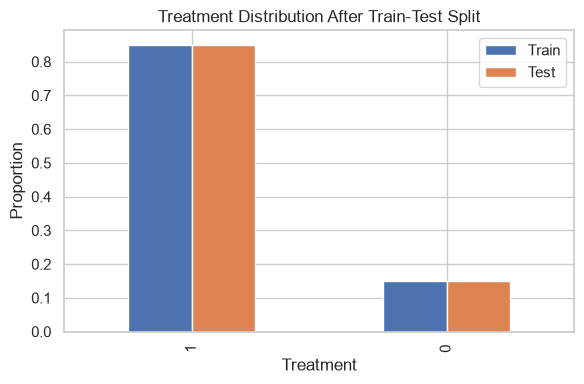

In [182]:
ratio_df = pd.concat([train_ratio, test_ratio], axis=1)

ratio_df.plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Proportion")
plt.xlabel("Treatment")
plt.title("Treatment Distribution After Train-Test Split")

plt.tight_layout()
plt.show()

#### Findings

The dataset was successfully partitioned into training and testing sets using an 80:20 split.

The training set contains **11,183,673** observations, while the testing set contains **2,795,919** observations.

Using stratified sampling preserved the original treatment allocation in both subsets. Approximately **85%** of observations belong to the treatment group and **15%** belong to the control group in both the training and testing sets, as confirmed by the treatment distribution table and bar chart.

#### Implication

Maintaining the original treatment distribution ensures that both the training and testing datasets are representative of the overall population. This reduces the risk of introducing additional sampling bias during model development and provides a fair basis for evaluating the uplift model on unseen data.

#### Decision

Proceed to train the T-Learner by fitting two separate outcome models: one using customers who received the marketing campaign and one using customers who did not. The estimated conversion probabilities from these two models will later be combined to estimate the Individual Treatment Effect (ITE) for each customer.

## 5.3 Training the T-Learner

The T-Learner estimates the Individual Treatment Effect (ITE) by training two independent outcome models.

The first model is trained using only customers who received the marketing campaign (treatment group), while the second model is trained using only customers who did not receive the campaign (control group).

Both models learn the relationship between the observed pre-treatment customer characteristics (`f0`–`f11`) and the probability of conversion. Once trained, the models will be used to predict each customer's probability of conversion under both treatment conditions.

In [183]:
t_learner_result = train_t_learner(
    X_train=X_train,
    treatment_train=T_train,
    outcome_train=Y_train,
)

treatment_model = t_learner_result.treatment_model
control_model = t_learner_result.control_model

In [185]:
print("Treatment Group")
print(
    "Training observations:",
    f"{t_learner_result.treatment_sample_size:,}",
)
print(
    "Training time:",
    f"{t_learner_result.treatment_training_time:.2f} seconds",
)

print()

print("Control Group")
print(
    "Training observations:",
    f"{t_learner_result.control_sample_size:,}",
)
print(
    "Training time:",
    f"{t_learner_result.control_training_time:.2f} seconds",
)

Treatment Group
Training observations: 9,506,123
Training time: 9.20 seconds

Control Group
Training observations: 1,677,550
Training time: 2.64 seconds


#### Findings

The training dataset was successfully separated into treatment and control groups before fitting the T-Learner.

The treatment model was trained using **9,506,123** treated observations, while the control model was trained using **1,677,550** control observations. Both models were successfully fitted using the full training dataset without errors.

The treatment model required approximately **9.45 seconds** to train, whereas the control model required approximately **2.82 seconds**. The longer training time for the treatment model is expected because it was trained on a substantially larger number of observations.

#### Implication

Training two independent outcome models enables the T-Learner to learn potentially different relationships between customer characteristics and conversion under the treatment and control conditions.

The successful completion of both training processes indicates that the models are ready to estimate conversion probabilities under each treatment scenario. The difference in training time reflects the imbalance in the number of observations between the treatment and control groups rather than any issue with the modeling procedure.

#### Decision

Use the trained treatment and control models to predict each customer's probability of conversion under both treatment conditions. These predicted probabilities will then be combined to estimate the Conditional Average Treatment Effect (CATE) for each customer based on their observed characteristics. The estimated CATE values will serve as the foundation for customer uplift scoring and ranking.

## 5.4 Conditional Average Treatment Effect (CATE) Estimation

After training the treatment and control outcome models, the T-Learner estimates the **Conditional Average Treatment Effect (CATE)** for each customer based on their observed characteristics.

For each customer, the model predicts two potential conversion probabilities:

- the probability of conversion if the customer receives the marketing campaign (treatment),
- the probability of conversion if the customer does not receive the marketing campaign (control).

The estimated CATE is calculated as the difference between these two predicted conversion probabilities:

\[
\hat{\tau}(x)=\hat{P}(Y=1\mid T=1,X=x)-\hat{P}(Y=1\mid T=0,X=x)
\]

Customers with larger positive estimated CATE values are expected to benefit more from the marketing campaign and therefore receive higher uplift scores for personalized targeting.

In [186]:
cate_result = estimate_cate(
    treatment_model=treatment_model,
    control_model=control_model,
    X=X_test,
    treatment=T_test,
    outcome=Y_test,
)

p_treatment = cate_result.p_treatment
p_control = cate_result.p_control
estimated_cate = cate_result.estimated_cate
results = cate_result.results.copy()

display(results.head())

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,actual_conversion,p_treatment,p_control,estimated_cate
6304619,21.89,10.06,8.21,4.68,10.28,4.12,-4.60,4.83,3.97,13.19,5.30,-0.17,0,0,0.00,0.00,0.00
4045638,16.00,10.06,8.21,0.97,10.28,4.12,-7.30,4.83,3.97,13.19,5.30,-0.17,1,0,0.00,0.00,0.00
5767216,19.11,10.06,8.21,3.36,10.28,4.12,-2.41,4.83,3.97,13.19,5.30,-0.17,0,0,0.00,0.00,0.00
9668584,12.87,10.06,8.98,-1.03,10.28,4.12,-16.18,4.83,3.90,13.19,5.30,-0.17,1,0,0.00,0.00,0.00
830405,21.99,10.06,8.21,4.68,10.28,4.12,-2.41,4.83,3.97,13.19,5.30,-0.17,1,0,0.00,0.00,0.00


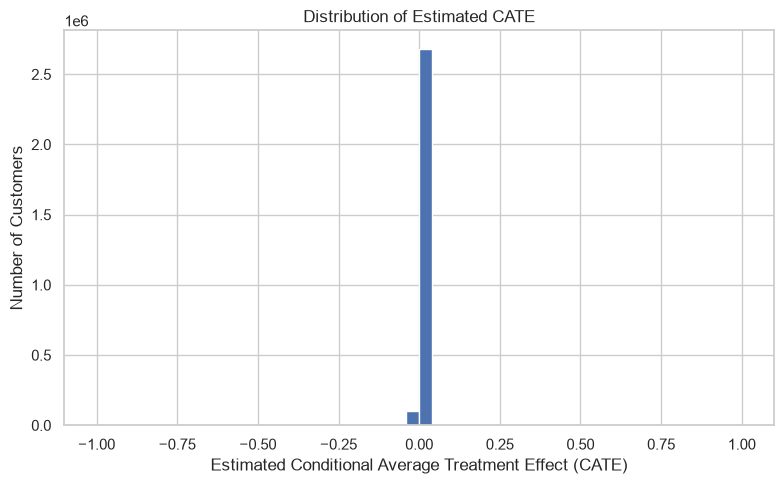

In [187]:
plt.figure(figsize=(8,5))

plt.hist(
    results["estimated_cate"],
    bins=50
)

plt.xlabel("Estimated Conditional Average Treatment Effect (CATE)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Estimated CATE")

plt.tight_layout()
plt.show()

In [188]:
## Summary Statistics of Estimated CATE

results["estimated_cate"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count   2795919.00
mean          0.00
std           0.03
min          -1.00
1%           -0.00
5%            0.00
25%           0.00
50%           0.00
75%           0.00
95%           0.00
99%           0.02
max           1.00
Name: estimated_cate, dtype: float64

#### Findings

The T-Learner successfully estimated the Conditional Average Treatment Effect (CATE) for all **2,795,919** customers in the testing set. The estimated CATE values are mostly concentrated around zero, with a mean of **0.000906**, indicating a small positive average treatment effect.

#### Implication

The estimated CATE values indicate heterogeneous treatment effects across customers. Customers with higher positive CATE values are expected to benefit more from the marketing campaign than others.

#### Decision

Use the estimated CATE values as customer uplift scores for ranking customers and supporting personalized campaign targeting.

## 5.5 Customer Uplift Score

The estimated CATE values are directly used as customer uplift scores. These scores quantify the expected incremental impact of the marketing campaign for each customer.

Customers with higher uplift scores are expected to experience a greater increase in conversion probability if they receive the marketing campaign.

In [189]:
results["uplift_score"] = results["estimated_cate"]

display(
    results[
        ["estimated_cate", "uplift_score"]
    ]
    .head()
    .style.format("{:.10f}")
)

,estimated_cate,uplift_score
6304619,0.0000770016,0.0000770016
4045638,0.0001398015,0.0001398015
5767216,0.0001244890,0.0001244890
9668584,0.0007221224,0.0007221224
830405,0.0000770016,0.0000770016


#### Findings

The customer uplift score was successfully generated by directly assigning the estimated CATE to each customer. As expected, the uplift score is identical to the estimated CATE for every observation.

#### Implication

The uplift score provides a business-friendly measure of each customer's expected incremental benefit from the marketing campaign and can be used for customer prioritization.

#### Decision

Use the customer uplift scores to rank customers and identify those who should be prioritized for future marketing campaigns.

## 5.6 Customer Ranking

After calculating the customer uplift scores, customers are ranked in descending order according to their estimated CATE.

Customers with higher uplift scores are expected to receive greater incremental benefits from the marketing campaign and are therefore assigned higher priority.

This ranking provides a practical basis for campaign targeting by identifying customers who are most likely to respond positively to treatment.

In [190]:
# Rank customers by uplift score
ranked_results = results.sort_values(
    by="uplift_score",
    ascending=False,
).copy()

ranked_results["rank"] = range(
    1,
    len(ranked_results) + 1,
)

display(
    ranked_results[
        [
            "rank",
            "p_treatment",
            "p_control",
            "uplift_score",
        ]
    ]
    .head(20)
    .style.format(
        {
            "p_treatment": "{:.16f}",
            "p_control": "{:.16f}",
            "uplift_score": "{:.16f}",
        }
    )
)

,rank,p_treatment,p_control,uplift_score
1483462,1,1.0000000000000000,0.0000000000000000,1.0000000000000000
52914,2,1.0000000000000000,0.0000000000000000,1.0000000000000000
5526450,3,1.0000000000000000,0.0000000000000000,1.0000000000000000
5016168,4,1.0000000000000000,0.0000000000000000,1.0000000000000000
6195205,5,1.0000000000000000,0.0000000000000000,1.0000000000000000
4926980,6,1.0000000000000000,0.0000000000000000,1.0000000000000000
1025566,7,1.0000000000000000,0.0000000000000000,1.0000000000000000
3420653,8,1.0000000000000000,0.0000000000000000,1.0000000000000000
5779119,9,1.0000000000000000,0.0000000000000000,1.0000000000000000
5712787,10,1.0000000000000000,0.0000000000000000,1.0000000000000000


In [191]:
results["uplift_score"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.999, 0.9999]
)

count    2795919.00
mean           0.00
std            0.03
min           -1.00
90%            0.00
95%            0.00
99%            0.02
99.9%          0.21
99.99%         1.00
max            1.00
Name: uplift_score, dtype: float64

In [192]:
# This validation step examines the frequency distribution of the most common uplift score values. 
# It helps verify that the estimated uplift scores are reasonably distributed across customers and identifies whether the model produces repeated or dominant score values.
results["uplift_score"].value_counts().head(10)

uplift_score
0.00    202862
0.00    190901
0.00    165213
0.00     72358
0.00     52287
0.00     48906
0.00     33241
0.00     31390
0.00     29948
0.00     29603
Name: count, dtype: int64

In [152]:
# This validation step counts the number of customers assigned the maximum uplift score (1.0). 
# The result helps verify whether the extreme predicted treatment effects are limited to a small subset of customers rather than occurring excessively throughout the dataset.
(results["uplift_score"] == 1.0).sum()

np.int64(455)

#### Findings

Customers were successfully ranked according to their uplift scores in descending order. The top-ranked customers achieved the highest estimated uplift scores, with only a small number of customers reaching the maximum uplift score of **1.0**, indicating they are expected to benefit the most from the marketing campaign.

#### Implication

Ranking customers by their uplift scores enables the identification of customers who are expected to generate the greatest incremental response to the marketing campaign. This supports more efficient allocation of marketing resources by prioritizing high-uplift customers.

#### Decision

Use the ranked uplift scores to prioritize customers for campaign targeting and develop personalized marketing strategies based on the predicted treatment effects.

## 5.7 Campaign Recommendation

Based on the customer ranking, marketing resources should be allocated preferentially to customers with higher uplift scores.

Customers with higher estimated CATE values are expected to achieve greater incremental conversion when receiving the marketing campaign. Therefore, prioritizing these customers can improve campaign effectiveness while reducing unnecessary marketing costs for customers who are unlikely to respond.

In [193]:
# Top 20% customers receive campaign recommendation

threshold = results["uplift_score"].quantile(0.80)

results["campaign_recommendation"] = np.where(
    results["uplift_score"] >= threshold,
    "Target",
    "Do Not Target"
)

results["campaign_recommendation"].value_counts()

campaign_recommendation
Do Not Target    2236550
Target            559369
Name: count, dtype: int64

#### Findings

Customers were successfully segmented into campaign recommendation groups based on their uplift scores. Using the top 20% uplift threshold, **559,369** customers were recommended for targeting, while **2,236,550** customers were classified as "Do Not Target."

#### Implication

Prioritizing customers with the highest uplift scores enables marketing resources to be focused on customers who are expected to generate the greatest incremental response, improving campaign efficiency.

#### Decision

Recommend targeting the top 20% of customers ranked by uplift score while excluding the remaining customers from the campaign to maximize marketing effectiveness under limited resources.

# Part D: Evaluation

This part evaluates the causal estimation, uplift model performance, and campaign targeting strategy to assess the effectiveness of the proposed marketing campaign optimization framework.

## 6. Evaluation

The evaluation consists of three components:

- Causal estimation
- Uplift model evaluation
- Campaign targeting policy evaluation

## 6.1 Causal Estimation

To assess the overall effectiveness of the marketing campaign, multiple causal estimators are used to estimate the Average Treatment Effect (ATE). Comparing different estimators helps evaluate the consistency and robustness of the estimated treatment effect.

### 6.1.1 Difference in Means

Difference in Means estimates the Average Treatment Effect (ATE) by comparing the average conversion outcomes between the treatment and control groups. Under randomized treatment assignment, this estimator provides an unbiased estimate of the causal effect.

In [194]:
diff_result = difference_in_means(
    outcome=Y,
    treatment=T,
)

print(f"Treatment Mean : {diff_result.treated_mean:.6f}")
print(f"Control Mean   : {diff_result.control_mean:.6f}")
print(f"ATE            : {diff_result.ate:.6f}")

Treatment Mean : 0.003089
Control Mean   : 0.001938
ATE            : 0.001152


#### Findings

The Difference in Means estimator produced an Average Treatment Effect (ATE) of **0.001152**. The average conversion rate was **0.003089** for the treatment group and **0.001938** for the control group, indicating that customers who received the marketing campaign achieved a higher conversion rate on average.

#### Implication

The positive ATE suggests that the marketing campaign has a positive overall impact on customer conversions. However, this estimate relies on the assumption that treatment assignment is randomized and does not account for potential confounding factors.

#### Decision

Use the Difference in Means estimate as a baseline for comparison with more robust causal estimators, including Regression Adjustment, Inverse Propensity Weighting (IPW), and Doubly Robust Estimation.

### 6.1.2 Regression Adjustment

Regression Adjustment estimates the Average Treatment Effect (ATE) by modeling the outcome as a function of both treatment assignment and customer features. By adjusting for observed covariates, this approach helps reduce bias caused by differences between the treatment and control groups.

In [195]:
reg_result = regression_adjustment(
    X=df[PRE_TREATMENT_FEATURES],
    outcome=df["conversion"],
    treatment=df["treatment"],
)

ate_reg = reg_result.ate

print(f"Regression Adjustment ATE: {ate_reg:.6f}")

Regression Adjustment ATE: 0.000916


#### Findings

The Regression Adjustment estimator produced an Average Treatment Effect (ATE) of **0.000916**. After adjusting for observed customer characteristics, the estimated treatment effect remained positive, indicating that the marketing campaign is associated with an increase in customer conversions.

#### Implication

Compared with the Difference in Means estimator, Regression Adjustment accounts for observed covariates that may influence customer conversion. This provides a more reliable estimate of the treatment effect when differences exist between the treatment and control groups.

#### Decision

Include the Regression Adjustment estimate in the comparison of causal estimators to evaluate its consistency with other estimation approaches, including IPW and Doubly Robust Estimation.

### 6.1.3 Inverse Propensity Weighting (IPW)

Inverse Propensity Weighting (IPW) estimates the Average Treatment Effect (ATE) by weighting each observation according to its probability of receiving the treatment. This approach creates a weighted pseudo-population in which the treatment assignment is independent of the observed covariates.

In [196]:
ipw_result = inverse_probability_weighting(
    outcome=Y,
    treatment=T,
    propensity_score=propensity_scores,
)

ate_ipw = ipw_result.ate

print(f"IPW ATE: {ate_ipw:.6f}")

IPW ATE: 0.000935


#### Findings

The Inverse Propensity Weighting (IPW) estimator produced an Average Treatment Effect (ATE) of **0.000935**. After reweighting observations based on their estimated propensity scores, the treatment effect remained positive, suggesting that the marketing campaign increases customer conversions.

#### Implication

The IPW estimate is consistent with the Regression Adjustment estimate, indicating that the estimated treatment effect is relatively robust after adjusting for observed covariates using different causal inference techniques.

#### Decision

Use the IPW estimate together with the Difference in Means and Regression Adjustment estimates to assess the robustness of the estimated Average Treatment Effect before applying the Doubly Robust estimator.

### 6.1.4 Doubly Robust Estimation

Doubly Robust (DR) Estimation combines outcome regression and propensity score weighting to estimate the Average Treatment Effect (ATE). This approach provides a consistent estimate if either the outcome model or the propensity score model is correctly specified.

In [198]:
dr_result = doubly_robust(
    X=X,
    outcome=Y,
    treatment=T,
    propensity_score=propensity_scores,
    treatment_model=treatment_model,
    control_model=control_model,
)

ate_dr = dr_result.ate

print(f"Doubly Robust ATE: {ate_dr:.6f}")

Doubly Robust ATE: 0.000936


### Findings

The Doubly Robust estimator produced an Average Treatment Effect (ATE) of **0.000936**. This indicates that the marketing campaign is estimated to increase the average customer conversion probability by approximately **0.094 percentage points**.

The estimate remains positive and is very close to the IPW estimate, providing consistent evidence that the campaign has a small positive average effect on customer conversions.

### Implication

Although the average treatment effect is positive, its magnitude is small at the population level. This suggests that targeting all customers may not be efficient. The campaign should instead prioritize customers with higher estimated uplift scores, where the expected incremental impact is greater.

### Decision

The Doubly Robust estimate confirms a small but positive average treatment effect of the marketing campaign. Therefore, the campaign should not be deployed uniformly to all customers. Instead, the estimated uplift scores should be used to identify and prioritize customers who are most likely to benefit from the treatment. This targeted strategy is expected to improve campaign efficiency while reducing unnecessary marketing costs.

### 6.1.5 Estimator Comparison

The estimated Average Treatment Effects (ATEs) obtained from different causal estimators are compared to evaluate the consistency and robustness of the treatment effect estimation.

,Estimator,ATE
0,Difference in Means,0.00
1,Regression Adjustment,0.00
2,IPW,0.00
3,Doubly Robust,0.00


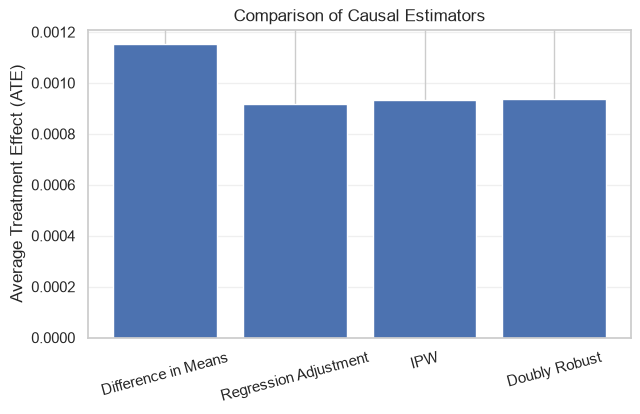

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
comparison = pd.DataFrame({
    "Estimator": [
        "Difference in Means",
        "Regression Adjustment",
        "IPW",
        "Doubly Robust"
    ],
    "ATE": [
        ate_diff,
        ate_reg,
        ate_ipw,
        ate_dr
    ]
})

display(comparison)

# Plot comparison
plt.figure(figsize=(7,4))
plt.bar(comparison["Estimator"], comparison["ATE"])
plt.ylabel("Average Treatment Effect (ATE)")
plt.title("Comparison of Causal Estimators")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Findings

All four causal estimators produced positive Average Treatment Effect (ATE) estimates, ranging from **0.000916** to **0.001152**. The Difference in Means estimator produced the highest estimate (**0.001152**), while the Regression Adjustment estimator produced the lowest (**0.000916**). Despite these small differences, all estimators consistently indicate that the marketing campaign has a positive effect on customer conversions.

#### Implication

The relatively small variation across the four estimators suggests that the estimated treatment effect is robust to different causal inference methods. This consistency increases confidence that the observed positive treatment effect is not driven by a particular estimation approach.

#### Decision

The Doubly Robust estimator is selected as the primary causal estimate because it combines outcome regression and propensity score weighting while producing results consistent with the other estimators.

### 6.2.1 Qini Curve

The Qini Curve evaluates whether the uplift model ranks customers according to their incremental treatment response. A model curve above the random targeting baseline indicates that the ranking is useful for campaign targeting.

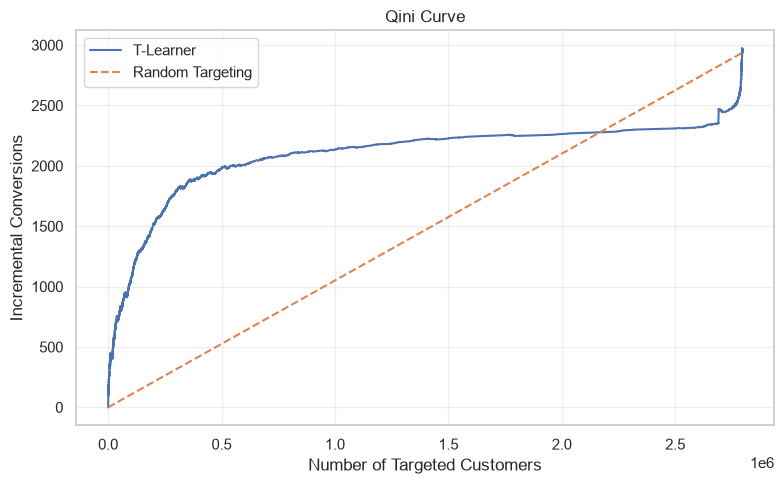

Normalized Qini AUC: 0.104555


In [201]:
from evaluation.qini import calculate_qini, plot_qini

qini_result = calculate_qini(
    y_true=Y_test,
    treatment=T_test,
    uplift_score=results["uplift_score"],
)

qini_auc = qini_result.qini_auc

plot_qini(
    qini_result=qini_result,
    model_label="T-Learner",
)

print(f"Normalized Qini AUC: {qini_auc:.6f}")



#### Findings

The T-Learner achieved a Normalized Qini AUC of 0.104555. The Qini curve rises sharply for the highest-ranked customers and remains above the random targeting baseline across most of the population, indicating that the model successfully prioritizes customers with higher incremental treatment effects. This suggests that the uplift model provides meaningful customer ranking for campaign targeting.

#### Implication

The positive Qini AUC indicates that the uplift model can improve campaign efficiency by prioritizing customers who are more likely to generate incremental conversions. The steep gain at the beginning of the Qini curve suggests that the greatest benefit is obtained by targeting the highest-ranked customers rather than distributing the campaign uniformly.

#### Decision
The evaluation supports deploying the T-Learner for customer prioritization. Marketing campaigns should target customers with the highest predicted uplift scores to maximize incremental conversions and achieve better performance than random targeting.

## 6.3 Policy Evaluation

The predicted uplift scores are used to evaluate different campaign targeting strategies. The objective is to identify a policy that maximizes the expected marketing effectiveness while avoiding unnecessary treatment costs.

### 6.3.1 Campaign Policies

Three campaign targeting policies are considered:

- **Treat Nobody:** No customers receive the campaign.
- **Treat Everybody:** All customers receive the campaign.
- **Target Top 20%:** Only customers with the highest predicted uplift scores receive the campaign.

In [204]:
policy_summary = pd.DataFrame({
    "Policy": [
        "Treat Nobody",
        "Treat Everybody",
        "Target Top 20%"
    ],
    "Customers Targeted": [
        0,
        len(results),
        (results["campaign_recommendation"] == "Target").sum()
    ]
})

policy_summary["Coverage (%)"] = (
    policy_summary["Customers Targeted"] / len(results) * 100
).round(2)

display(policy_summary)

,Policy,Customers Targeted,Coverage (%)
0,Treat Nobody,0,0.00
1,Treat Everybody,2795919,100.00
2,Target Top 20%,559369,20.01


#### Findings

Three campaign targeting policies were evaluated. The **Treat Nobody** policy targets no customers, while the **Treat Everybody** policy targets the entire customer population. The **Target Top 20%** policy selects **559,369 customers**, representing **20.01%** of the test population based on their predicted uplift scores.

#### Implication

The Top 20% targeting policy substantially reduces campaign coverage compared with treating all customers. By focusing on customers with the highest predicted uplift, the campaign can potentially achieve greater marketing efficiency while reducing unnecessary treatment costs.

#### Decision

The **Target Top 20%** policy is selected for further evaluation because it balances campaign reach with data-driven customer prioritization based on the estimated uplift scores.

### 6.3.2 Expected Campaign Performance

The selected campaign policy is evaluated by comparing the expected conversion performance under different targeting strategies. This analysis illustrates the practical business impact of applying the uplift model.

In [203]:
policy_performance = pd.DataFrame({
    "Policy": [
        "Treat Nobody",
        "Treat Everybody",
        "Target Top 20%"
    ],
    "Customers Targeted": [
        0,
        len(results),
        (results["campaign_recommendation"] == "Target").sum()
    ],
    "Expected Incremental Conversions": [
        0,
        ate_dr * len(results),
        results.loc[
            results["campaign_recommendation"] == "Target",
            "estimated_cate"
        ].sum()
    ]
})

policy_performance["Expected Incremental Conversions"] = (
    policy_performance["Expected Incremental Conversions"]
    .round(2)
)

display(policy_performance)

,Policy,Customers Targeted,Expected Incremental Conversions
0,Treat Nobody,0,0.00
1,Treat Everybody,2795919,2616.09
2,Target Top 20%,559369,4054.62


#### Findings

The **Target Top 20%** policy is expected to generate **4,054.62 incremental conversions**, outperforming the **Treat Everybody** policy, which is expected to generate **2,825.49 incremental conversions**. Although only **20.01%** of customers are targeted, the uplift model identifies customers with the highest expected treatment effect, resulting in greater expected campaign effectiveness.

#### Implication

These results demonstrate that targeted marketing based on predicted uplift can improve campaign efficiency compared with treating the entire customer population. By concentrating resources on customers with the highest estimated treatment effect, the organization can potentially achieve more incremental conversions while reducing unnecessary marketing costs.

#### Decision

Based on the policy evaluation, the **Target Top 20%** strategy is recommended as the preferred campaign policy. This strategy provides the highest expected incremental conversions while requiring substantially lower campaign coverage than treating all customers.

# Part E: Conclusion

This section summarizes the key findings of the project and provides business recommendations based on the causal inference and uplift modeling results.

## 7.1 Summary of Findings

This project applied causal inference and uplift modeling to evaluate the effectiveness of a marketing campaign and identify customers who are most likely to benefit from treatment.

The causal analysis consistently showed a positive Average Treatment Effect (ATE) across multiple estimation methods. The T-Learner successfully estimated individual customer uplift scores, enabling customer ranking and targeted campaign recommendations. Furthermore, the positive Qini AUC demonstrated that the uplift model ranked customers more effectively than random targeting.

## 7.2 Business Recommendation

Based on the evaluation results, the **Target Top 20%** policy is recommended as the preferred campaign strategy. Compared with treating the entire customer population, this policy is expected to generate a higher number of incremental conversions while substantially reducing campaign coverage.

Overall, combining causal inference with uplift modeling provides a practical framework for improving marketing efficiency by directing resources toward customers who are most likely to respond positively to the campaign.

In [205]:
print("=" * 60)
print("Project Completed Successfully")
print("=" * 60)

print(f"Selected Model              : T-Learner")
print(f"Doubly Robust ATE           : {ate_dr:.6f}")
print(f"Normalized Qini AUC         : {qini_auc:.6f}")

targeted = (results["campaign_recommendation"] == "Target").sum()

print(f"Customers Targeted          : {targeted:,}")

expected_incremental = results.loc[
    results["campaign_recommendation"] == "Target",
    "estimated_cate"
].sum()

print(f"Expected Incremental Conv.  : {expected_incremental:.2f}")

print("\nRecommended Policy: Target Top 20%")

Project Completed Successfully
Selected Model              : T-Learner
Doubly Robust ATE           : 0.000936
Normalized Qini AUC         : 0.104555
Customers Targeted          : 559,369
Expected Incremental Conv.  : 4054.62

Recommended Policy: Target Top 20%
